# Appendix-Brr_fluctuation

In [1]:
%pwd

'/home/tzuhsuan/GitHub/QFoam/High-fidelity-Rydberg-control-Z-gates-with-time-optimal-pulses/Manuscript-figures'

In [11]:
import os
import glob
import time
from IPython.display import clear_output

from qutip import *
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from rdquantum.pulse_shape import Saffman_shape
from rdquantum.fidelity import fidelity
from rdquantum.optimizer.de import de

# plt.rcParams["figure.figsize"] = [5.5, 6]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50

Brr_test = np.arange(-10, 10, 0.5)

In [19]:
Fi_Brr_2D = []

# Add Gaussian500_53S_5L_BrrX 2D plot
root_dir = "Gaussian500_53S_5L_BrrX"
data_dir_prefix = "Gaussian500_53S_5L_Brr"
brr = [50, 100, 250, 500]
for i in range(len(brr)):
    Fi_Brr_2D.append(np.load("../{}/{}{}/out_brr_roubustness.npy".format(root_dir, data_dir_prefix, brr[i]), allow_pickle=True))

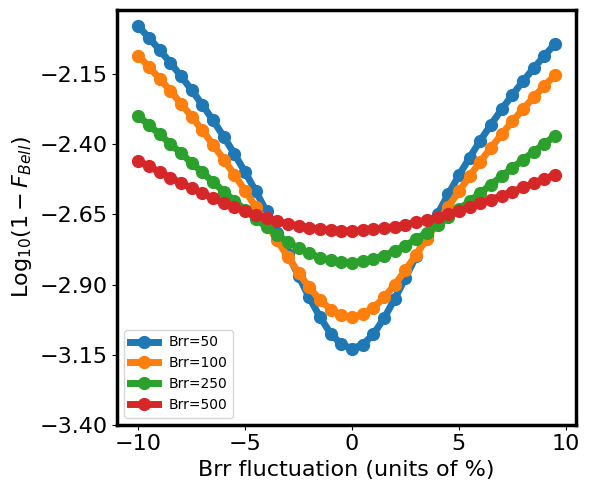

In [25]:
fig, axs = plt.subplots(figsize=(6, 5))
ax2d = plt.subplot()

# Delta2_2D
for i in range(len(Fi_Brr_2D)):
    ax2d.plot(Brr_test, [np.log10(1-x) for x in Fi_Brr_2D[i]], '-o', markersize=8.5, linewidth=5, label="Brr={}".format(brr[i]))
yinterval_2d = np.arange(-3.4, -2, 0.25)
xinterval_2d = np.arange(-10, 10.5, 2.5)
ax2d.set_yticks(yinterval_2d)
# ax2d.set_xticks(xinterval_2d)
ax2d.tick_params(axis='x', labelsize=16)
ax2d.tick_params(axis='y', labelsize=16)
ax2d.legend(fontsize=10)
ax2d.set_xlabel('Brr fluctuation' ' (units of %)', fontsize=16)
ax2d.set_ylabel('Log' r'$_{10}$' r'$(1-F_{Bell})$', fontsize=16)
# ax2d.set_title('c)', x=-0.18, pad=15, fontsize=24)

plt.tight_layout()
plt.savefig('brr_fluctuation.png', dpi=1200)